In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, KFold

tkwargs = {
    "dtype": torch.double, 
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

seed = 0

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(7,16, **tkwargs),
            nn.Sigmoid(),
            nn.Linear(16,32),
            nn.Sigmoid(),
            nn.Linear(32,16),
            nn.Sigmoid(),
            nn.Linear(16,1)
        )

    def forward(self, X):
        return self.layers(X)

    def fit(self, X_train, y_train, X_test=None, y_test=None, n_epochs=1000, lr=0.01, verbose=False, plot=False):
        # Switch to training mode
        self.train()
        # Initialize loss function and optimizer
        loss_fn = nn.MSELoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        # Initialize lists to store loss
        if plot:
            train_loss_hist = []
            test_loss_hist = []
        # Training loop
        for epoch in range(n_epochs):
            # Forward pass
            y_pred_train = self(X_train).flatten()
            train_loss = loss_fn(y_pred_train, y_train)
            if plot:
                train_loss_hist.append(train_loss.item())
            # Backward pass
            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()
            # Compute test loss if test data is provided
            if X_test is not None and y_test is not None:
                self.eval()
                with torch.no_grad():
                    y_pred_test = self(X_test).flatten()
                    test_loss = loss_fn(y_pred_test, y_test)
                    if plot:
                        test_loss_hist.append(test_loss.item())
                self.train()
            # Print loss
            if verbose and (epoch+1) % 100 == 0:
                if X_test is not None and y_test is not None:
                    print(f"Epoch {epoch+1}/{n_epochs}: Train Loss = {train_loss.item()} - Test Loss = {test_loss.item()}")
                else:
                    print(f"Epoch {epoch+1}/{n_epochs}: Train Loss = {train_loss.item()}")
        # Generate plot
        if plot:
            plt.plot(train_loss_hist, label="Train Loss")
            if X_test is not None and y_test is not None:
                plt.plot(test_loss_hist, label="Test Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()
        # Trained model evaluation
        self.eval()
        with torch.no_grad():
            y_pred_train = self(X_train)
            R2_train = r2_score(y_train.cpu().numpy(), y_pred_train.cpu().numpy())
            MSE_train = mean_squared_error(y_train.cpu().numpy(), y_pred_train.cpu().numpy())
            if X_test is not None and y_test is not None:
                y_pred_test = self(X_test)
                R2_test = r2_score(y_test.cpu().numpy(), y_pred_test.cpu().numpy())
                MSE_test = mean_squared_error(y_test.cpu().numpy(), y_pred_test.cpu().numpy())
                return R2_train, MSE_train, R2_test, MSE_test
            else:
                return R2_train, MSE_train

    def predict(self, X):
        # Switch to evaluation mode
        self.eval()
        with torch.no_grad():
            return self(X)

In [115]:
epoch = 99
(epoch + 1) % 100

0

In [118]:
def loadData():
    data = np.concatenate([
        np.load('data/real_data.npy'),
        np.load('data/iter1_data.npy'),
        np.load('data/iter2_data.npy')
    ])
    return torch.Tensor(data).to(**tkwargs)

def myKFold(X, y, k = 5, n_epochs = 1000, lr = 1e-2, verbose = False, plot = False):
    # Initialize the KFold object
    kf = KFold(n_splits = k, shuffle = True, random_state = 0)

    # Split the training set k times
    for i, (train_idx, test_idx) in enumerate(kf.split(X)):
        # Create the model
        mdl = MLP().to(**tkwargs)
        R2_train, MSE_train, R2_test, MSE_test = mdl.fit(
            X[train_idx], 
            y[train_idx], 
            X[test_idx], 
            y[test_idx], 
            n_epochs = n_epochs, 
            lr = lr, 
            verbose = verbose, 
            plot = plot
        )
        print(f"Fold {i+1}/{k}: Train MSE = {MSE_train:.3f}, Test MSE = {MSE_test:.3f} | Train R2 = {R2_train:.3f}, Test R2 = {R2_test:.3f}")

In [122]:
data = loadData()

X = data[:,:-2]
y = data[:,-1]

mdl = MLP().to(**tkwargs)
myKFold(X, y, k = 5, n_epochs = 2000, lr = 1e-2, verbose = False, plot = False)

Fold 1/5: Train MSE = 31.450, Test MSE = 55.039 | Train R2 = 0.948, Test R2 = 0.892
Fold 2/5: Train MSE = 46.368, Test MSE = 67.827 | Train R2 = 0.918, Test R2 = 0.894
Fold 3/5: Train MSE = 29.473, Test MSE = 75.557 | Train R2 = 0.951, Test R2 = 0.858
Fold 4/5: Train MSE = 41.540, Test MSE = 73.707 | Train R2 = 0.928, Test R2 = 0.879
Fold 5/5: Train MSE = 30.673, Test MSE = 56.193 | Train R2 = 0.947, Test R2 = 0.906


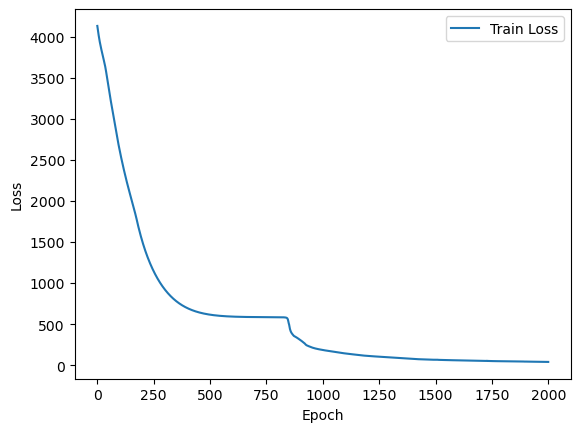

In [123]:
data = loadData()

X = data[:,:-2]
y = data[:,-1]

mdl = MLP().to(**tkwargs)
mdl.fit(X, y, n_epochs = 2000, lr = 1e-2, verbose = False, plot = True)
plt.show()

In [124]:
torch.save(mdl.state_dict(), 'models/MLP.pth')

In [16]:
mdl = MLP().to(**tkwargs)
mdl.load_state_dict(torch.load('models/surrogate.pth', weights_only = True))

<All keys matched successfully>

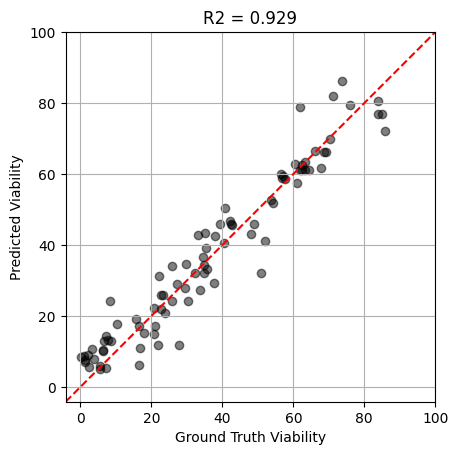

In [20]:
iter1 = torch.Tensor(np.load('data/data_iter1.npy')).to(**tkwargs)
iter2 = torch.Tensor(np.load('data/data_iter2.npy')).to(**tkwargs)
iter1 = torch.cat([iter1, iter2], dim = 0)

y_true = iter1[:,-1].cpu().numpy()
y_pred = mdl(iter1[:,:-2]).detach().cpu().numpy()

fig, ax = plt.subplots()

ax.scatter(y_true, y_pred, c = 'black', alpha = 0.5)
ax.set_xlabel('Ground Truth Viability')
ax.set_ylabel('Predicted Viability')

ax.set_aspect('equal')
ax.set_xlim([ax.get_xlim()[0],100])
ax.set_ylim([ax.get_xlim()[0],100])
ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [ax.get_xlim()[0], ax.get_xlim()[1]], 'r--')
ax.grid()
ax.set_title(f"R2 = {r2_score(y_true, y_pred):.3f}")

plt.show()

In [18]:
torch.save(mdl.state_dict(), 'models/MLP.pth')